# Algoritmo de Dijkstra
Este notebook apresenta uma explicação completa do algoritmo de Dijkstra, com exemplos visuais, pseudocódigo, exercícios guiados e um mini jogo interativo com grafos ponderados.

## 🧠 O que é o Algoritmo de Dijkstra?
O algoritmo de Dijkstra é uma técnica para encontrar o **caminho mais curto** entre um nó inicial e os demais nós em um grafo **ponderado com pesos positivos**.

É muito utilizado em problemas de:
- Rotas (como no Google Maps)
- Redes de computadores
- Logística e transporte

### Características:
- Só funciona com **pesos positivos** nas arestas.
- Encontra o menor custo do nó inicial para todos os outros nós.

## 🧾 Pseudocódigo do Algoritmo de Dijkstra
```text
1. Marque todos os nós com distância infinita, exceto o nó inicial (distância 0).
2. Marque todos os nós como não visitados.
3. Escolha o nó não visitado com menor distância atual.
4. Para cada vizinho desse nó:
    a. Calcule a distância até o vizinho.
    b. Se for menor que a atual, atualize.
5. Marque o nó como visitado.
6. Repita até visitar todos os nós ou encontrar o destino.
```

## Vamos testar primeiramente como funciona uma heap

In [1]:
import heapq

# criando uma fila de prioridade
pq = []

# adicionando pares (custo, nó) para manter o menor custo no topo
heapq.heappush(pq, (5, 'B'))
heapq.heappush(pq, (2, 'A'))
heapq.heappush(pq, (4, 'C'))

# mostrando a fila de prioridade após a adição dos nós
print(pq)

# removendo o elemento com menor custo atual
menor = heapq.heappop(pq)
print('Removido da heap:', menor)

# mostrando a fila de prioridade após a remoção
print(pq)


[(2, 'A'), (5, 'B'), (4, 'C')]
Removido da heap: (2, 'A')
[(4, 'C'), (5, 'B')]


## Exemplo Simples: Grafo Ponderado Pequeno

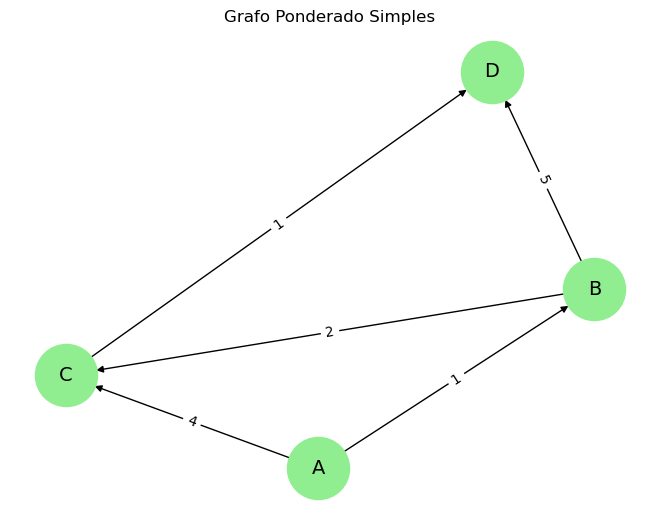

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
G.add_weighted_edges_from([
    ('A', 'B', 1),
    ('A', 'C', 4),
    ('B', 'C', 2),
    ('B', 'D', 5),
    ('C', 'D', 1)
])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=14)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Grafo Ponderado Simples")
plt.show()

## Exercício: Calcule manualmente o caminho mais curto de A até D usando o grafo acima.

Tente aplicar o pseudocódigo passo a passo no papel ou quadro.

## Implementação de Dijkstra

In [3]:
from collections import defaultdict
import heapq

def dijkstra(graph, start):
    # distância padrão infinita para qualquer nó ainda não alcançado
    dist = defaultdict(lambda: float('inf'))
    parent = {start: None}
    dist[start] = 0

    # heap com pares (distância acumulada, nó atual)
    pq = [(0, start)]
    visited = set()

    while pq:
        current_dist, node = heapq.heappop(pq)

        # se o nó já foi processado, ignoramos esta entrada repetida
        if node in visited:
            continue
        visited.add(node)

        # relaxamento das arestas que saem do nó atual
        for neighbor, weight in graph[node]:
            new_dist = current_dist + weight
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                parent[neighbor] = node
                heapq.heappush(pq, (new_dist, neighbor))

    return dist, parent

G = {
    'A': [('B', 1), ('C', 4)],
    'B': [('C', 2), ('D', 5)],
    'C': [('D', 1)],
    'D': []
}

# Execução
distances, parents = dijkstra(G, 'A')
print('Distâncias mínimas:', dict(distances))


Distâncias mínimas: {'A': 0, 'B': 1, 'C': 3, 'D': 4}


In [4]:
def show_path(parents, goal):
    path = []

    # reconstruímos o caminho voltando do destino até a origem
    while goal:
        path.insert(0, goal)
        goal = parents.get(goal)

    return path

print('\nCaminho de A até D:')
print(' -> '.join(show_path(parents, 'D')))



Caminho de A até D:
A -> B -> C -> D


Qual o caminho mais curto?
Qual é o menor caminho de `A` até `D`?

In [5]:
# na versão solution, já deixamos a resposta correta preenchida
resposta = 'A B C D'
correto = ' '.join(show_path(parents, 'D'))

print('Resposta escolhida:', resposta)

if resposta.upper() == correto.upper():
    print('Parabéns! Você acertou o caminho.')
else:
    print(f'Resposta incorreta. O caminho correto é: {correto}')


Resposta escolhida: A B C D
Parabéns! Você acertou o caminho.


## Vamos agora testar com este grafo

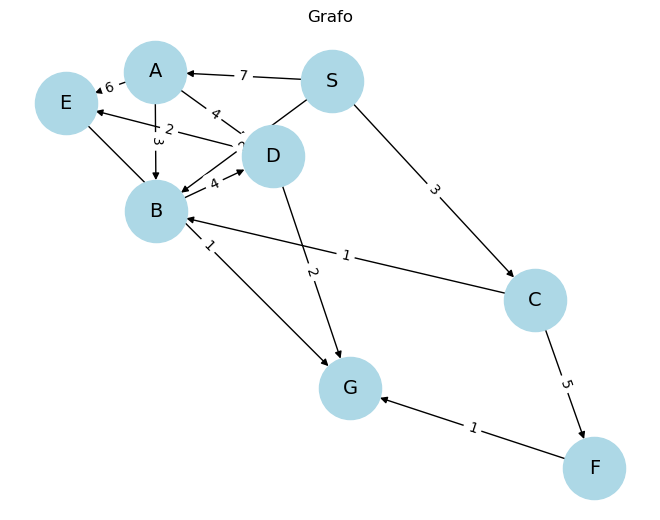

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

# Dicionário de adjacência com pesos
G_dict = {
    'S': {('A', 7), ('B', 2), ('C', 3)},
    'A': {('B', 3), ('D', 4), ('E', 6)},
    'B': {('D', 4)},
    'C': {('B', 1), ('F', 5)},
    'D': {('E', 2), ('G', 2)},
    'E': {('G', 1)},
    'F': {('G', 1)},
    'G': set()
}

# Criando um grafo direcionado do NetworkX
G_nx = nx.DiGraph()

# Adicionando as arestas e pesos
for node in G_dict:
    for neighbor, weight in G_dict[node]:
        G_nx.add_edge(node, neighbor, weight=weight)

# Visualização do grafo
pos = nx.spring_layout(G_nx, seed=42)
nx.draw(G_nx, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=14)
labels = nx.get_edge_attributes(G_nx, 'weight')
nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=labels)
plt.title("Grafo")
plt.show()


In [7]:
G = {
    'S': {('A', 7), ('B', 2), ('C', 3)},
    'A': {('B', 3), ('D', 4), ('E', 6)},
    'B': {('D', 4)},
    'C': {('B', 1), ('F', 5)},
    'D': {('E', 2), ('G', 2)},
    'E': {('G', 1)},
    'F': {('G', 1)},
    'G': set()
}


In [8]:
# executando Dijkstra a partir de S no grafo maior
distancias_grafo_maior, pais_grafo_maior = dijkstra(G, 'S')

print('Distâncias mínimas a partir de S:')
for no in sorted(distancias_grafo_maior):
    print(f'  S -> {no}: {distancias_grafo_maior[no]}')

print('\nMelhor caminho de S até G:')
print(' -> '.join(show_path(pais_grafo_maior, 'G')))


Distâncias mínimas a partir de S:
  S -> A: 7
  S -> B: 2
  S -> C: 3
  S -> D: 6
  S -> E: 8
  S -> F: 8
  S -> G: 8
  S -> S: 0

Melhor caminho de S até G:
S -> B -> D -> G
